Standaryzacja datasetu
Wczytaj cały dataset Iris (4 cechy). Zaimplementuj standaryzację (mean=0, std=1) dla każdej cechy używając operacji NumPy. 
Porównaj wynik z StandardScaler z sklearn.

Wymagania:
Oblicz mean i std per kolumna ( axis=0 )
Zastosuj wzór: (X - mean) / std
Sprawdź mean i std po standaryzacji
Porównaj z sklearn.preprocessing.StandardScaler
Oblicz max różnicę między implementacjami

Oczekiwany rezultat:
Macierz X_standardized (150, 4)
Weryfikacja: mean≈0, std≈1
Max różnica vs sklearn


In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
#pd.set_option('display.width', 10000)


# Wczytanie Iris dataset
iris = load_iris()

X = iris.data # Macierz cech (150, 4).  - 150 Observations (instances) ,  4 Features
y = iris.target # Wektor etykiet (150,) - 

print("Kształt macierzy cech:", X.shape) # 150 obserwacji, 4 cechy
print(f"Feature Name: {iris.feature_names}")
print("="*30)

print("Kształt wektora etykiet:", y.shape) # 150 etykiet
print(f"Target Name: {iris.target_names}")
print("="*30)
# Pierwszy kwiat (obserwacja) jako wektor cech
kwiat_0 = X[0]
kwiat_1 = X[1]
kwiat_2 = X[2]

print("Pierwszy kwiat (wektor cech):", kwiat_0)
print("Drugi kwiat (wektor cech):", kwiat_1)
print("Trzeci kwiat (wektor cech):", kwiat_2)
#print("Cechy: sepal_length, sepal_width, petal_length, petal_width")



Kształt macierzy cech: (150, 4)
Feature Name: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Kształt wektora etykiet: (150,)
Target Name: ['setosa' 'versicolor' 'virginica']
Pierwszy kwiat (wektor cech): [5.1 3.5 1.4 0.2]
Drugi kwiat (wektor cech): [4.9 3.  1.4 0.2]
Trzeci kwiat (wektor cech): [4.7 3.2 1.3 0.2]
Cechy: sepal_length, sepal_width, petal_length, petal_width


In [28]:
print(iris.data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [16]:
print(iris.target) # 0 = setosa,  1 = versicolor, 2 = virginica

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [62]:

print("="*60)
xx = [2.1 , 2.5, 2.7, 3, 2.4, 2.5, 2.3]
mean_xx = np.mean(xx)
std_xx = np.std(xx)
print(f"Srednia xx : {mean_xx}") 
print(f"Std xx : {std_xx}") # średniae być taka same w róznych grupach  ale Std rózne. 
#IF Wartości STD blisko siebie (wyniki podobne) = małe STD.
# IF STD daleko od siebie (rozócone) = duze STD.
#Standard Deviation mówi jak wyniki róznią się  od siebie.  Miara rozrzutu.

# Dane w miare równe uzyj Mean i STD
# Dane bardzo skośne uzyj Mediana i Rozstęp Międzykwartylowy
# https://www.youtube.com/watch?v=X-tg6txdNks

xx_standardized = (xx - mean_xx) / std_xx
xx_standardized_rounded = np.round(xx_standardized, 4)
print("\nZstandaryzowane xx :")
print(xx_standardized_rounded)

print("="*60)
# Weryfikacja: średnia ≈ 0, std ≈ 1
print(f"\nPo standaryzacji:")
print(f" Średnia per Feature: {xx_standardized.mean()}")
print(f" Std per Feature: {xx_standardized.std()}")

Srednia xx : 2.5
Std xx : 0.2672612419124244

Zstandaryzowane xx :
[-1.4967  0.      0.7483  1.8708 -0.3742  0.     -0.7483]

Po standaryzacji:
 Średnia per Feature: 0.0
 Std per Feature: 1.0


In [64]:
mean = X.mean(axis=0) # Średnia per Feature (4 wartości)
std = X.std(axis=0) # Odchylenie standardowe per Feature (4 wartości)
print(f"\nŚrednia per Feature: {mean}")
print(f"Std per Feature: {std}")

# Broadcasting: (150, 4) - (4,) = (150, 4)
X_standardized = (X - mean) / std
print("\nZstandaryzowane dane (5 pierwszych):")
print(X_standardized[:5])


Średnia per Feature: [5.84333333 3.05733333 3.758      1.19933333]
Std per Feature: [0.82530129 0.43441097 1.75940407 0.75969263]

Zstandaryzowane dane (5 pierwszych):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
# Weryfikacja: średnia ≈ 0, std ≈ 1
print(f"\nPo standaryzacji:")
print(f" Średnia per Feature: {X_standardized.mean(axis=0)}")
print(f" Std per Feature: {X_standardized.std(axis=0)}")


# Porównanie z sklearn
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sklearn = scaler.fit_transform(X)
print("\nRóżnica (nasza vs sklearn):")
print(f" Max różnica: {np.abs(X_standardized - X_sklearn).max():.4f}")


Po standaryzacji:
 Średnia per Feature: [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
 Std per Feature: [1. 1. 1. 1.]

Różnica (nasza vs sklearn):
 Max różnica: 0.0000


In [22]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = iris.data.astype(float)  # shape (150,4)

# 1) Oblicz mean i std per kolumna (axis=0) — zgodnie ze StandardScaler używamy std populacyjnego (ddof=0)
means = X.mean(axis=0)
stds = X.std(axis=0)  # domyślnie ddof=0

# 2) Standaryzacja własna: (X - mean) / std
X_std_np = (X - means) / stds
print("\nZstandaryzowane dane (5 pierwszych):")
print(X_std_np[:5])

# 3) Weryfikacja: mean ≈ 0, std ≈ 1
means_after = X_std_np.mean(axis=0)
stds_after = X_std_np.std(axis=0)

print("Means before standardization:", np.round(means, 6))
print("Stds before standardization: ", np.round(stds, 6))
print("Means after (numpy):         ", np.round(means_after, 6))
print("Stds after (numpy):          ", np.round(stds_after, 6))

# 4) Porównanie ze StandardScaler
scaler = StandardScaler()
X_std_sklearn = scaler.fit_transform(X)

# 5) Maksymalna różnica między implementacjami
max_diff = np.abs(X_std_np - X_std_sklearn).max()
print("Max absolute difference vs StandardScaler:", max_diff)



Zstandaryzowane dane (5 pierwszych):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]
Means before standardization: [5.843333 3.057333 3.758    1.199333]
Stds before standardization:  [0.825301 0.434411 1.759404 0.759693]
Means after (numpy):          [-0. -0. -0. -0.]
Stds after (numpy):           [1. 1. 1. 1.]
Max absolute difference vs StandardScaler: 0.0


Zadanie 10 – Macierz odległości dla k-NN
Wybierz 10 losowych obserwacji z Iris. 
Oblicz pełną macierz odległości euklidesowych
(10×10) między wszystkimi parami. Wizualizuj jako heatmapę.
Dataset:
    Iris (sklearn.datasets.load_iris)

Wymagania:
    Losowo wybierz 10 obserwacji (użyj np.random.choice na indeksach)
    Użyj euclidean_distances z sklearn lub zagnieżdżone pętle
    Wizualizuj macierz jako heatmapę (seaborn.heatmap lub plt.imshow)
    Diagonala powinna być 0 (odległość od samego siebie)

Oczekiwany rezultat:
    Macierz 10×10
    Heatmapa z annotacjami

Wybrane indeksy: [ 73  18 118  78  76  31  64 141  68  82]
Macierz odległości 10x10:
 [[0.     3.3121 2.9411 0.3873 0.7348 3.4249 1.2166 1.4491 0.7071 0.8602]
 [3.3121 0.     6.0399 3.1906 3.6097 0.5477 2.3302 4.1821 3.4771 2.6211]
 [2.9411 6.0399 0.     3.0627 2.4637 6.2209 4.0485 2.0322 2.9682 3.7189]
 [0.3873 3.1906 3.0627 0.     0.866  3.2894 1.005  1.3601 0.728  0.728 ]
 [0.7348 3.6097 2.4637 0.866  0.     3.7696 1.7029 1.     0.9055 1.3638]
 [3.4249 0.5477 6.2209 3.2894 3.7696 0.     2.3473 4.3486 3.5057 2.6552]
 [1.2166 2.3302 4.0485 1.005  1.7029 2.3473 0.     2.2316 1.3038 0.4243]
 [1.4491 4.1821 2.0322 1.3601 1.     4.3486 2.2316 0.     1.5166 2.005 ]
 [0.7071 3.4771 2.9682 0.728  0.9055 3.5057 1.3038 1.5166 0.     0.9274]
 [0.8602 2.6211 3.7189 0.728  1.3638 2.6552 0.4243 2.005  0.9274 0.    ]]
Diagonal (powinna być 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


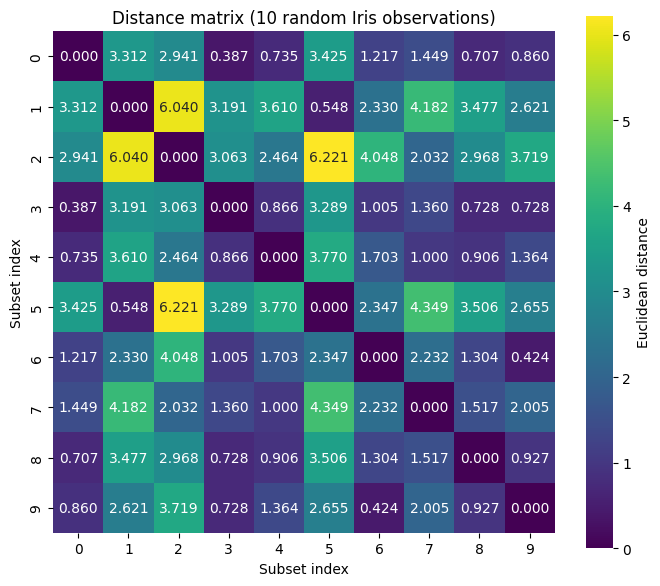


Test sample index: 75
Test sample features: [6.6 3.  4.4 1.4]
Prawdziwa klasa: 1 (versicolor)

Odległości do wszystkich 150 obserwacji (pierwsze 10):
[3.5972 3.651  3.8341 3.7229 3.6551 3.2465 3.7908 3.5454 3.9102 3.6056]

5 najbliższych sąsiadów:
 1. Obserwacja 75: odległość=0.000, klasa=1 (versicolor)
 2. Obserwacja 65: odległość=0.141, klasa=1 (versicolor)
 3. Obserwacja 58: odległość=0.245, klasa=1 (versicolor)
 4. Obserwacja 74: odległość=0.265, klasa=1 (versicolor)
 5. Obserwacja 54: odległość=0.316, klasa=1 (versicolor)

Predykcja k-NN (k=5): klasa 1 (versicolor)
Prawdziwa klasa: 1 (versicolor)
Poprawna predykcja: True


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics.pairwise import euclidean_distances
from scipy.stats import mode

np.random.seed(42)

# Wczytanie danych
iris = load_iris()
X = iris.data      # (150,4)
y = iris.target

# --- Część A: 10 losowych obserwacji -> macierz odległości 10x10 + heatmapa ---
idx = np.random.choice(X.shape[0], size=10, replace=False)
X_sub = X[idx]
print("Wybrane indeksy:", idx)

dist_matrix = euclidean_distances(X_sub, X_sub)  # (10,10)
print("Macierz odległości 10x10:\n", np.round(dist_matrix, 4))

# Diagonal powinno być 0
print("Diagonal (powinna być 0):", np.diag(dist_matrix))

# Heatmapa z annotacjami
plt.figure(figsize=(7,6))
sns.heatmap(dist_matrix, annot=True, fmt=".3f", cmap="viridis", square=True,
            cbar_kws={'label': 'Euclidean distance'})
plt.title("Distance matrix (10 random Iris observations)")
plt.xlabel("Subset index")
plt.ylabel("Subset index")
plt.xticks(np.arange(10)+0.5, range(10))
plt.yticks(np.arange(10)+0.5, range(10))
plt.tight_layout()
plt.show()

# --- Część B: przykład k-NN dla pojedynczej obserwacji (test_sample) ---
test_idx = 75
test_sample = X[test_idx].reshape(1, -1)  # (1,4)
print(f"\nTest sample index: {test_idx}")
print("Test sample features:", test_sample[0])
print(f"Prawdziwa klasa: {y[test_idx]} ({iris.target_names[y[test_idx]]})")

# Odległości test_sample -> wszystkie obserwacje
distances = euclidean_distances(test_sample, X)[0]  # (150,)
print("\nOdległości do wszystkich 150 obserwacji (pierwsze 10):")
print(np.round(distances[:10], 4))

# k-NN: znajdź k najbliższych sąsiadów
k = 5
nearest_indices = np.argsort(distances)[:k]
nearest_distances = distances[nearest_indices]
nearest_labels = y[nearest_indices]

print(f"\n{k} najbliższych sąsiadów:")
for i, (idx_n, dist, label) in enumerate(zip(nearest_indices, nearest_distances, nearest_labels), 1):
    print(f" {i}. Obserwacja {idx_n}: odległość={dist:.3f}, klasa={label} ({iris.target_names[label]})")

# Predykcja: najczęstsza klasa wśród sąsiadów
predicted_class = mode(nearest_labels, keepdims=True).mode[0]
print(f"\nPredykcja k-NN (k={k}): klasa {predicted_class} ({iris.target_names[predicted_class]})")
print(f"Prawdziwa klasa: {y[test_idx]} ({iris.target_names[y[test_idx]]})")
print("Poprawna predykcja:", predicted_class == y[test_idx])